<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day5_Mini_Project_Marketing_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Mini-Projet US Superstore — Bloc 1 : Chargement & Preprocessing
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration esthétique
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement du dataset depuis GitHub (format Excel .xls)
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls"
df = pd.read_excel(url)

# Aperçu du dataset
print("Shape :", df.shape)
print("\nColumns :", df.columns.tolist())
print("\nPremiers enregistrements :")
df.head()

Shape : (9994, 21)

Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Premiers enregistrements :


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# ============================================================
# Bloc 2 : Preprocessing & nettoyage
# ============================================================

# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Vérification des types
print("\nTypes des colonnes :")
print(df.dtypes)

# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Création de colonnes utiles pour l'analyse
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

# Statistiques descriptives
print("\nStatistiques descriptives :")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

Valeurs manquantes par colonne :
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Types des colonnes :
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name         

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


Top 10 États par ventes totales :
State
California      457687.63
New York        310876.27
Texas           170188.05
Washington      138641.27
Pennsylvania    116511.91
Florida          89473.71
Illinois         80166.10
Ohio             78258.14
Michigan         76269.61
Virginia         70636.72
Name: Sales, dtype: float64


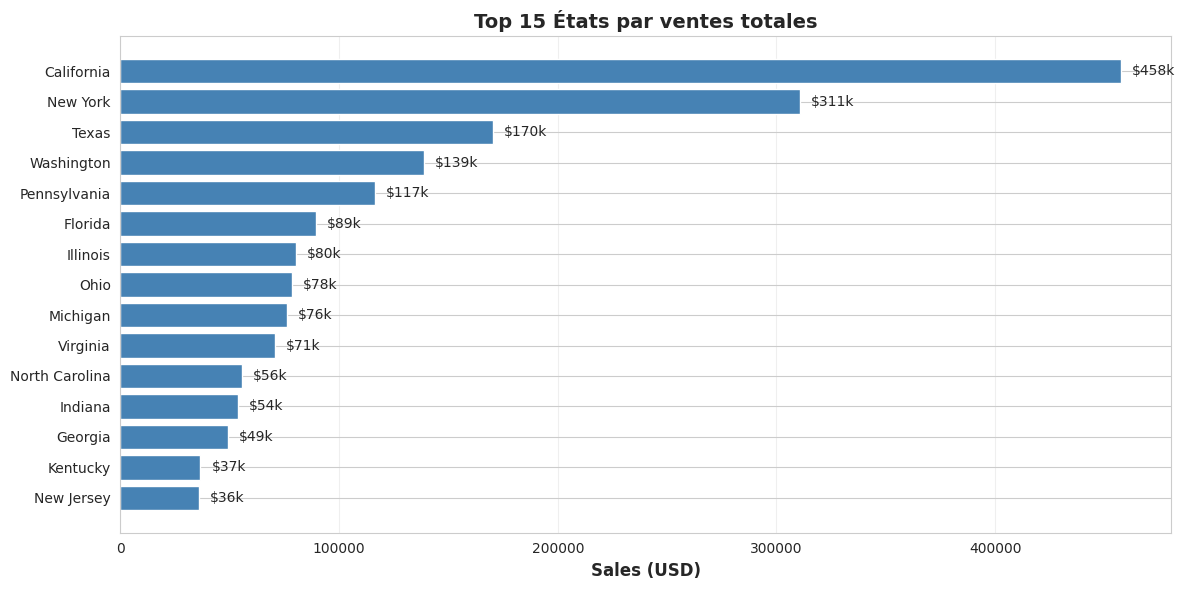


→ Total ventes USA : $2,297,201
→ État leader : California ($457,688)


In [3]:
# ============================================================
# Bloc 3 : Quels états ont le plus de ventes ?
# ============================================================

# Agrégation des ventes par état (somme totale)
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

print("Top 10 États par ventes totales :")
print(state_sales.head(10).round(2))

# Visualisation : Top 15 États
top15 = state_sales.head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')
plt.xlabel('Sales (USD)', fontsize=12, fontweight='bold')
plt.title('Top 15 États par ventes totales', fontsize=14, fontweight='bold')

# Ajout des valeurs sur les barres
for bar, val in zip(bars, top15.values[::-1]):
    plt.text(val + 5000, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}k', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n→ Total ventes USA : ${state_sales.sum():,.0f}")
print(f"→ État leader : {state_sales.index[0]} (${state_sales.iloc[0]:,.0f})")

Comparaison New York vs California :
                    New York  California
Sales (USD)        310876.27   457687.63
Profit (USD)        74038.55    76381.39
Nb commandes         1128.00     2001.00
Profit Margin (%)      23.82       16.69


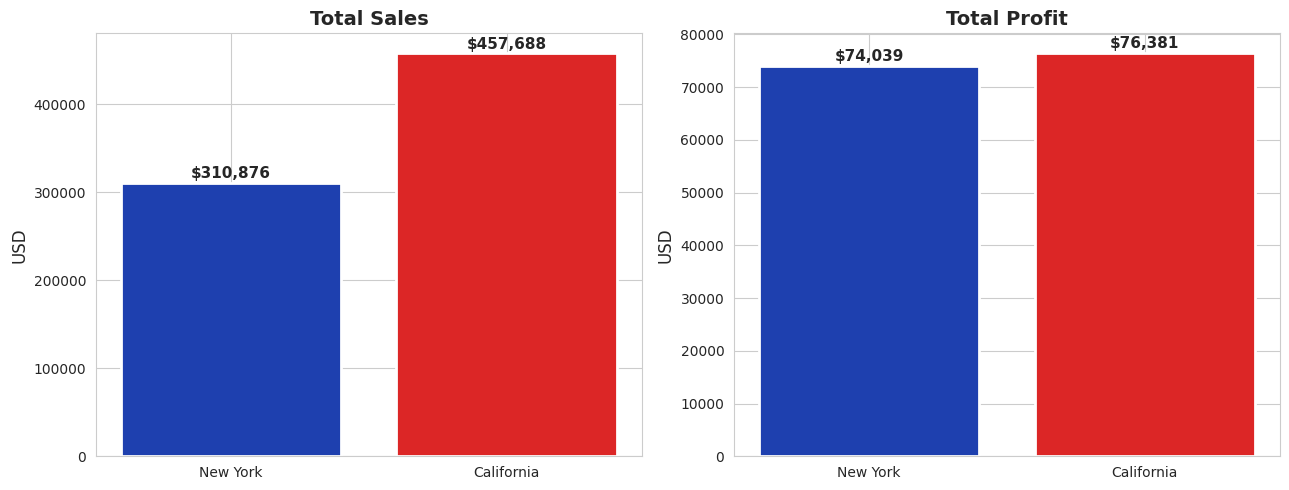


→ California vend $146,811 de plus que New York (47.2% en plus)
→ California génère $2,343 de profit de plus que New York


In [4]:
# ============================================================
# Bloc 4 : Comparaison New York vs California
# ============================================================

# Filtrage des deux états
ny_data = df[df['State'] == 'New York']
ca_data = df[df['State'] == 'California']

# Calcul des KPI pour chaque état
comparison = pd.DataFrame({
    'New York'   : [ny_data['Sales'].sum(), ny_data['Profit'].sum(),
                    len(ny_data), ny_data['Profit'].sum() / ny_data['Sales'].sum() * 100],
    'California' : [ca_data['Sales'].sum(), ca_data['Profit'].sum(),
                    len(ca_data), ca_data['Profit'].sum() / ca_data['Sales'].sum() * 100],
}, index=['Sales (USD)', 'Profit (USD)', 'Nb commandes', 'Profit Margin (%)'])

print("Comparaison New York vs California :")
print(comparison.round(2))

# Visualisation : barres groupées Sales vs Profit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : Sales
states = ['New York', 'California']
sales_vals = [ny_data['Sales'].sum(), ca_data['Sales'].sum()]
profit_vals = [ny_data['Profit'].sum(), ca_data['Profit'].sum()]

colors = ['#1E40AF', '#DC2626']
bars1 = axes[0].bar(states, sales_vals, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Total Sales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('USD', fontsize=12)
for bar, val in zip(bars1, sales_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5000,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Graphique 2 : Profit
bars2 = axes[1].bar(states, profit_vals, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Total Profit', fontsize=14, fontweight='bold')
axes[1].set_ylabel('USD', fontsize=12)
for bar, val in zip(bars2, profit_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1000,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Calcul des différences
diff_sales = ca_data['Sales'].sum() - ny_data['Sales'].sum()
diff_profit = ca_data['Profit'].sum() - ny_data['Profit'].sum()

print(f"\n→ California vend ${diff_sales:,.0f} de plus que New York ({diff_sales/ny_data['Sales'].sum()*100:.1f}% en plus)")
print(f"→ California génère ${diff_profit:,.0f} de profit de plus que New York")

Top 10 clients de New York par profit :
                  Total_Sales  Total_Profit  Nb_Orders  Avg_Discount
Customer Name                                                       
Tom Ashbrook         13723.50       4599.21          2          0.04
Keith Dawkins         5854.19       2510.89          2          0.02
Karen Daniels         6241.28       2283.05          2          0.07
Nathan Mautz          4821.29       2247.19          2          0.05
Tom Boeckenhauer      6999.96       2239.99          1          0.00
Steven Roelle         3904.68       1863.96          3          0.00
Pete Kriz             4816.69       1695.32          2          0.08
Darrin Martin         4283.79       1599.68          1          0.06
Todd Sumrall          6492.31       1574.97          2          0.04
Seth Vernon           7359.92       1571.80          1          0.04

Top 10 clients de New York par ventes :
                  Total_Sales  Total_Profit  Nb_Orders  Avg_Discount
Customer Name         

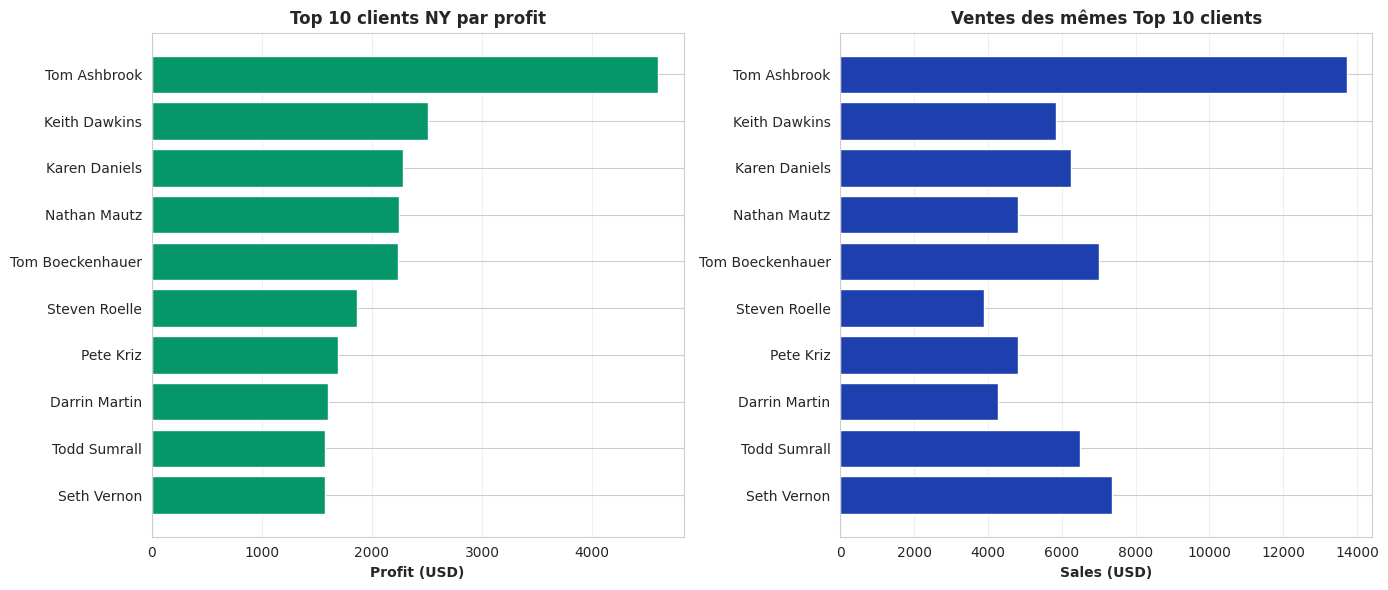


⭐ Client exceptionnel à New York : Tom Ashbrook
   • Profit total  : $4,599.21
   • Ventes totales: $13,723.50
   • Nb commandes  : 2


In [5]:
# ============================================================
# Bloc 5 : Client exceptionnel à New York
# ============================================================

# Filtrer NY puis agréger par client
ny_customers = df[df['State'] == 'New York'].groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Nb_Orders=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2)

# Tri par profit décroissant (le critère "exceptionnel")
top_ny_customers = ny_customers.sort_values('Total_Profit', ascending=False)

print("Top 10 clients de New York par profit :")
print(top_ny_customers.head(10))

print("\nTop 10 clients de New York par ventes :")
print(ny_customers.sort_values('Total_Sales', ascending=False).head(10))

# Visualisation : Top 10 par profit
top10 = top_ny_customers.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Profit
axes[0].barh(top10.index[::-1], top10['Total_Profit'].values[::-1],
             color='#059669', edgecolor='white')
axes[0].set_xlabel('Profit (USD)', fontweight='bold')
axes[0].set_title('Top 10 clients NY par profit', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Sales
axes[1].barh(top10.index[::-1], top10['Total_Sales'].values[::-1],
             color='#1E40AF', edgecolor='white')
axes[1].set_xlabel('Sales (USD)', fontweight='bold')
axes[1].set_title('Ventes des mêmes Top 10 clients', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Mise en avant du client exceptionnel (top profit)
top_customer = top_ny_customers.index[0]
print(f"\n⭐ Client exceptionnel à New York : {top_customer}")
print(f"   • Profit total  : ${top_ny_customers.iloc[0]['Total_Profit']:,.2f}")
print(f"   • Ventes totales: ${top_ny_customers.iloc[0]['Total_Sales']:,.2f}")
print(f"   • Nb commandes  : {int(top_ny_customers.iloc[0]['Nb_Orders'])}")

Top 10 États les plus rentables (par profit) :
            Total_Sales  Total_Profit  Nb_Orders  Profit_Margin_%
State                                                            
California    457687.63      76381.39       1021            16.69
New York      310876.27      74038.55        562            23.82
Washington    138641.27      33402.65        256            24.09
Michigan       76269.61      24463.19        117            32.07
Virginia       70636.72      18597.95        115            26.33
Indiana        53555.36      18382.94         73            34.33
Georgia        49095.84      16250.04         91            33.10
Kentucky       36591.75      11199.70         61            30.61
Minnesota      29863.15      10823.19         44            36.24
Delaware       27451.07       9977.37         44            36.35

Top 10 États les MOINS rentables (déficitaires) :
                Total_Sales  Total_Profit  Nb_Orders  Profit_Margin_%
State                                   

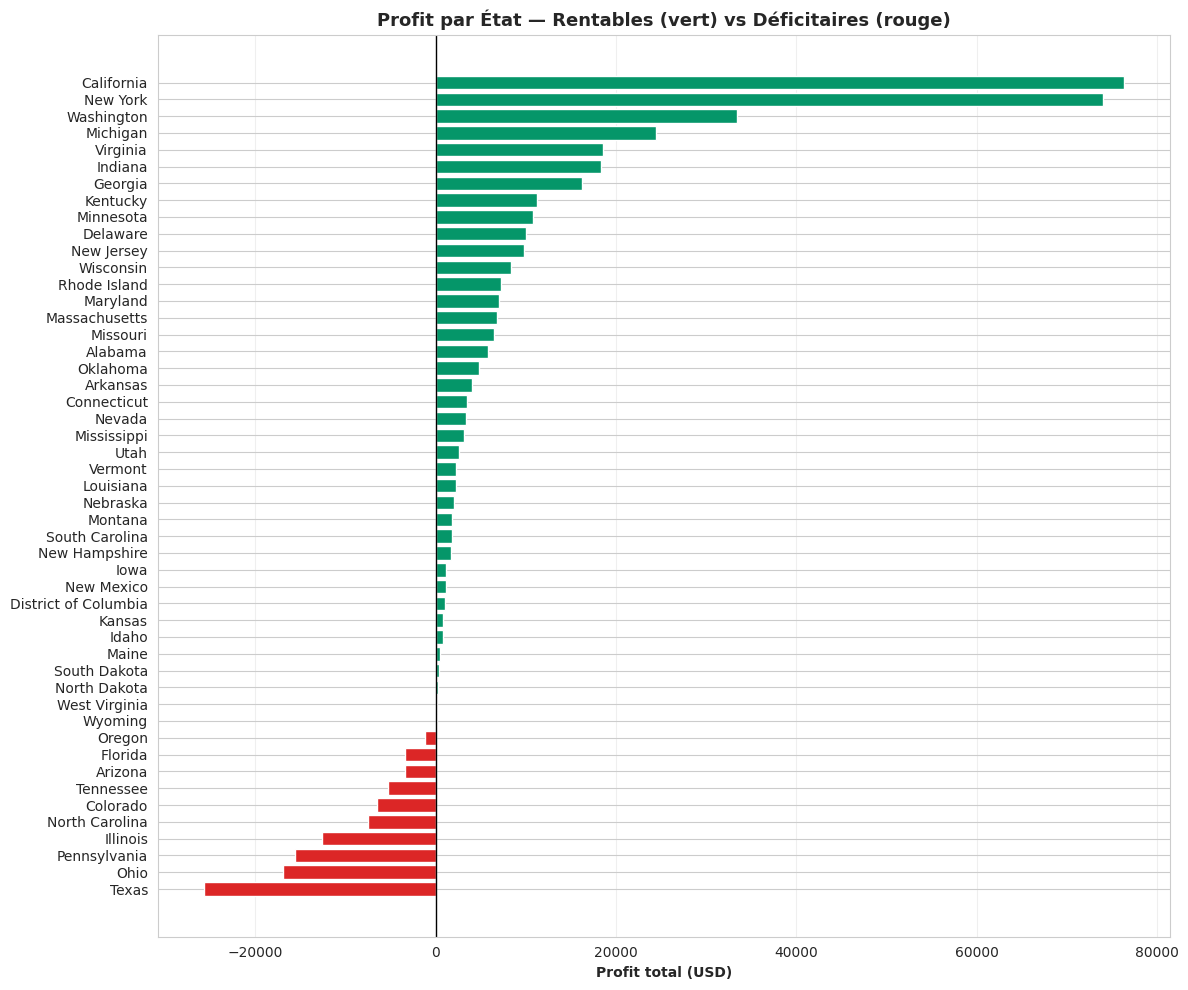


→ Nombre d'États déficitaires : 10
→ Perte cumulée : $-98,246.74

→ État le plus rentable : California ($76,381.39)
→ État le plus déficitaire : Texas ($-25,729.36)


In [6]:
# ============================================================
# Bloc 6 : Différences de rentabilité entre États
# ============================================================

# Agrégation : ventes, profit et marge par État
state_profit = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Nb_Orders=('Order ID', 'nunique')
).round(2)

# Marge de profit en %
state_profit['Profit_Margin_%'] = (state_profit['Total_Profit'] / state_profit['Total_Sales'] * 100).round(2)

# Tri par profit décroissant
state_profit_sorted = state_profit.sort_values('Total_Profit', ascending=False)

print("Top 10 États les plus rentables (par profit) :")
print(state_profit_sorted.head(10))

print("\nTop 10 États les MOINS rentables (déficitaires) :")
print(state_profit_sorted.tail(10))

# Visualisation : barplot diverging (États rentables vs déficitaires)
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#059669' if x > 0 else '#DC2626' for x in state_profit_sorted['Total_Profit']]
ax.barh(state_profit_sorted.index[::-1], state_profit_sorted['Total_Profit'].values[::-1],
        color=colors[::-1], edgecolor='white')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Profit total (USD)', fontweight='bold')
ax.set_title('Profit par État — Rentables (vert) vs Déficitaires (rouge)', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# États déficitaires
loss_states = state_profit_sorted[state_profit_sorted['Total_Profit'] < 0]
print(f"\n→ Nombre d'États déficitaires : {len(loss_states)}")
print(f"→ Perte cumulée : ${loss_states['Total_Profit'].sum():,.2f}")
print(f"\n→ État le plus rentable : {state_profit_sorted.index[0]} (${state_profit_sorted.iloc[0]['Total_Profit']:,.2f})")
print(f"→ État le plus déficitaire : {state_profit_sorted.index[-1]} (${state_profit_sorted.iloc[-1]['Total_Profit']:,.2f})")

Nombre total de clients : 793
Profit total : $286,397.02

→ Il faut 19.3% des clients (153 clients) pour atteindre 80% du profit
→ Les 20% top clients (158 clients) génèrent 81.4% du profit


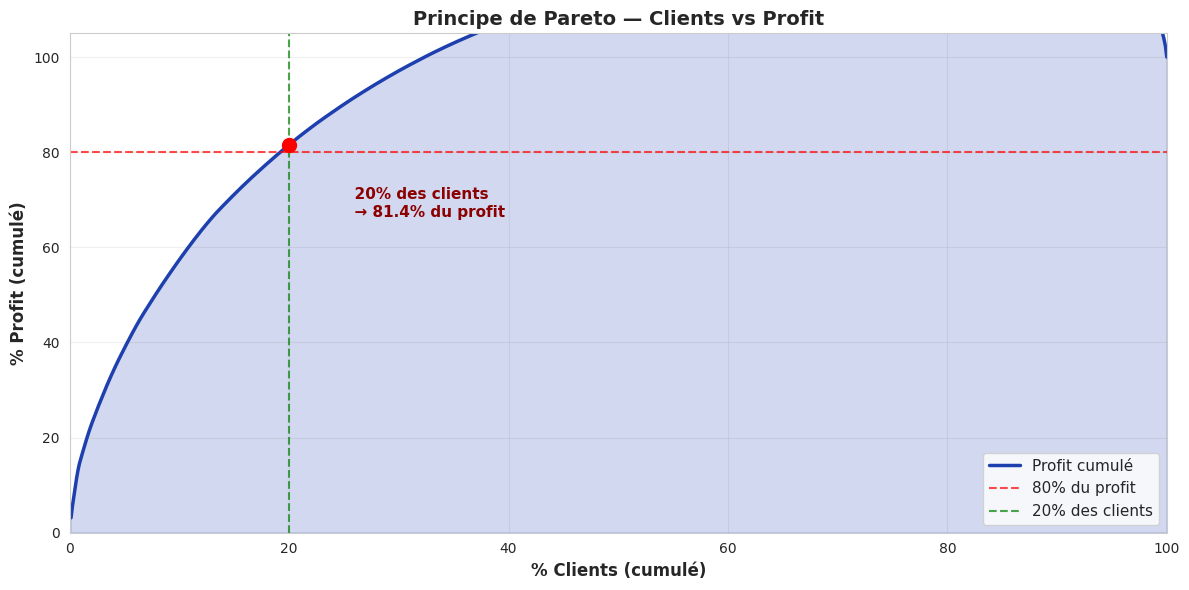


✅ Principe de Pareto VÉRIFIÉ : 20% des clients génèrent 81.4% du profit


In [7]:
# ============================================================
# Bloc 7 : Application du Principe de Pareto (Clients & Profit)
# Hypothèse : 20% des clients génèrent 80% du profit ?
# ============================================================

# Agrégation profit par client
customer_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

# Profit cumulé
cumulative_profit = customer_profit.cumsum()
total_profit = customer_profit.sum()
cumulative_pct = (cumulative_profit / total_profit) * 100

# Pourcentage de clients
n_customers = len(customer_profit)
customer_pct = (np.arange(1, n_customers + 1) / n_customers) * 100

# Identification du seuil 80% du profit
idx_80 = np.argmax(cumulative_pct.values >= 80)
pct_customers_for_80 = customer_pct[idx_80]

print(f"Nombre total de clients : {n_customers}")
print(f"Profit total : ${total_profit:,.2f}")
print(f"\n→ Il faut {pct_customers_for_80:.1f}% des clients ({idx_80+1} clients) pour atteindre 80% du profit")

# Vérification précise au seuil 20%
idx_20pct = int(n_customers * 0.20)
profit_top20pct = cumulative_pct.iloc[idx_20pct - 1]
print(f"→ Les 20% top clients ({idx_20pct} clients) génèrent {profit_top20pct:.1f}% du profit")

# Visualisation : courbe de Pareto (Lorenz)
plt.figure(figsize=(12, 6))
plt.plot(customer_pct, cumulative_pct.values, color='#1E40AF', linewidth=2.5, label='Profit cumulé')
plt.fill_between(customer_pct, cumulative_pct.values, alpha=0.2, color='#1E40AF')

# Lignes de référence 20/80
plt.axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% du profit')
plt.axvline(20, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='20% des clients')
plt.scatter([20], [profit_top20pct], color='red', s=100, zorder=5)
plt.annotate(f'  20% des clients\n  → {profit_top20pct:.1f}% du profit',
             xy=(20, profit_top20pct), xytext=(25, profit_top20pct - 15),
             fontsize=11, fontweight='bold', color='darkred')

plt.xlabel('% Clients (cumulé)', fontweight='bold', fontsize=12)
plt.ylabel('% Profit (cumulé)', fontweight='bold', fontsize=12)
plt.title('Principe de Pareto — Clients vs Profit', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# Conclusion
if profit_top20pct >= 75:
    print(f"\n✅ Principe de Pareto VÉRIFIÉ : 20% des clients génèrent {profit_top20pct:.1f}% du profit")
else:
    print(f"\n⚠️ Principe de Pareto NON strictement vérifié : 20% des clients = {profit_top20pct:.1f}% du profit (proche de 80%)")

Top 20 villes par VENTES :
               Total_Sales  Total_Profit  Nb_Orders  Profit_Margin_%
City                                                                
New York City    256368.16      62036.98        450            24.20
Los Angeles      175851.34      30440.76        384            17.31
Seattle          119540.74      29156.10        212            24.39
San Francisco    112669.09      17507.39        265            15.54
Philadelphia     109077.01     -13837.77        265           -12.69
Houston           64504.76     -10153.55        188           -15.74
Chicago           48539.54      -6654.57        171           -13.71
San Diego         47521.03       6377.20         88            13.42
Jacksonville      44713.18      -2323.84         61            -5.20
Springfield       43054.34       6200.70         73            14.40
Detroit           42446.94      13181.79         53            31.05
Columbus          38706.24       5897.10        111            15.24
Newark 

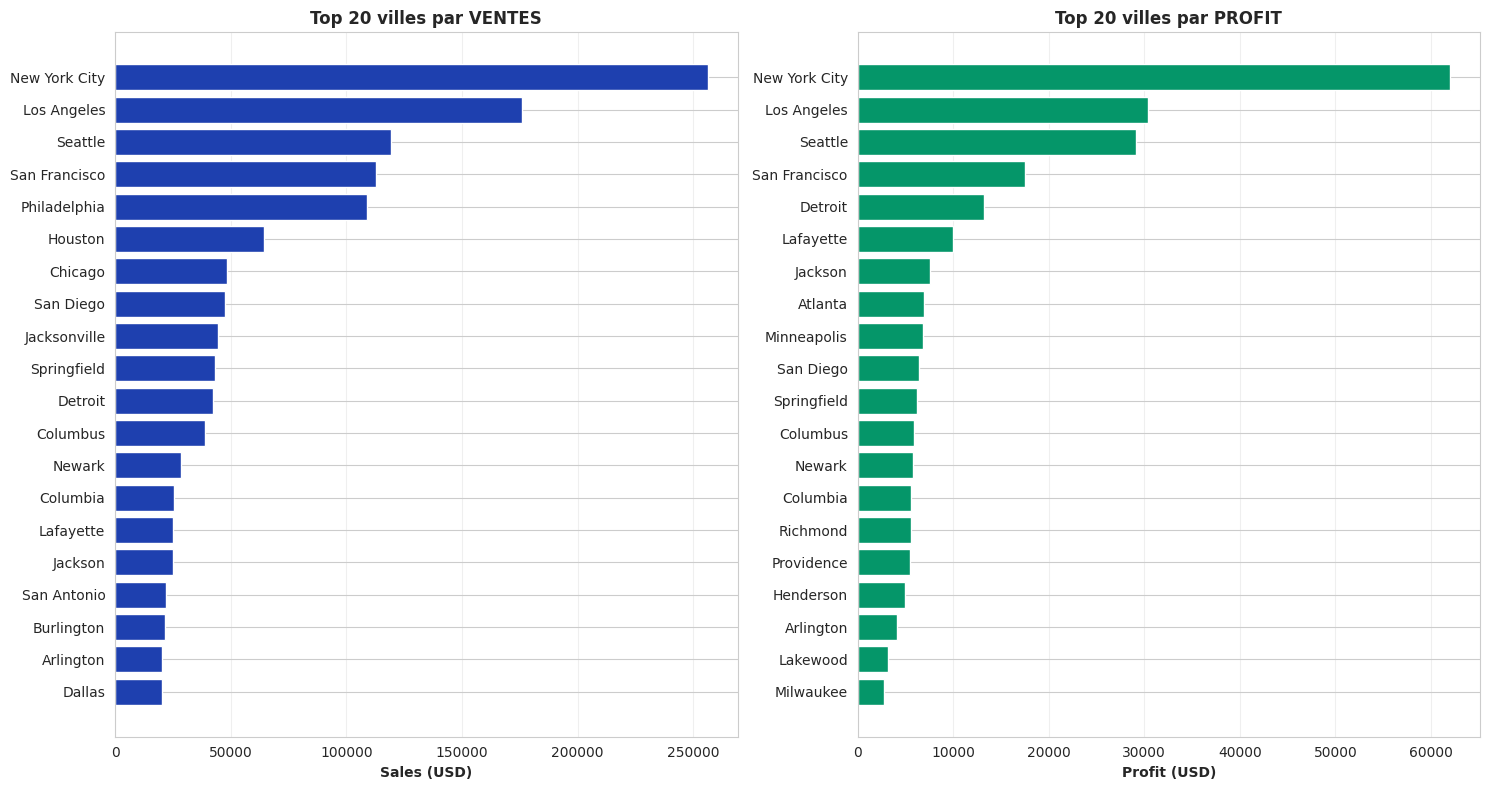


→ 13 villes sont à la fois dans le Top 20 Sales ET Top 20 Profit
   Villes communes : ['Arlington', 'Columbia', 'Columbus', 'Detroit', 'Jackson', 'Lafayette', 'Los Angeles', 'New York City', 'Newark', 'San Diego', 'San Francisco', 'Seattle', 'Springfield']

⚠️ Villes à gros volume mais HORS Top 20 Profit (7) :
   ['Burlington', 'Chicago', 'Dallas', 'Houston', 'Jacksonville', 'Philadelphia', 'San Antonio']

💎 Villes très rentables mais HORS Top 20 Sales (7) :
   ['Atlanta', 'Henderson', 'Lakewood', 'Milwaukee', 'Minneapolis', 'Providence', 'Richmond']


In [8]:
# ============================================================
# Bloc 8 : Top 20 villes par Sales et par Profit
# ============================================================

# Agrégation par ville
city_stats = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Nb_Orders=('Order ID', 'nunique')
).round(2)

city_stats['Profit_Margin_%'] = (city_stats['Total_Profit'] / city_stats['Total_Sales'] * 100).round(2)

# Top 20 par ventes et par profit
top20_sales  = city_stats.sort_values('Total_Sales', ascending=False).head(20)
top20_profit = city_stats.sort_values('Total_Profit', ascending=False).head(20)

print("Top 20 villes par VENTES :")
print(top20_sales)

print("\nTop 20 villes par PROFIT :")
print(top20_profit)

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Top 20 par Sales
axes[0].barh(top20_sales.index[::-1], top20_sales['Total_Sales'].values[::-1],
             color='#1E40AF', edgecolor='white')
axes[0].set_xlabel('Sales (USD)', fontweight='bold')
axes[0].set_title('Top 20 villes par VENTES', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Top 20 par Profit
colors_profit = ['#059669' if x > 0 else '#DC2626' for x in top20_profit['Total_Profit']]
axes[1].barh(top20_profit.index[::-1], top20_profit['Total_Profit'].values[::-1],
             color=colors_profit[::-1], edgecolor='white')
axes[1].set_xlabel('Profit (USD)', fontweight='bold')
axes[1].set_title('Top 20 villes par PROFIT', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Comparaison : combien de villes sont dans les 2 tops ?
common_cities = set(top20_sales.index) & set(top20_profit.index)
print(f"\n→ {len(common_cities)} villes sont à la fois dans le Top 20 Sales ET Top 20 Profit")
print(f"   Villes communes : {sorted(common_cities)}")

# Villes uniquement dans Top Sales (gros volume mais peu rentable)
sales_only = set(top20_sales.index) - set(top20_profit.index)
print(f"\n⚠️ Villes à gros volume mais HORS Top 20 Profit ({len(sales_only)}) :")
print(f"   {sorted(sales_only)}")

# Villes uniquement dans Top Profit (petites villes très rentables)
profit_only = set(top20_profit.index) - set(top20_sales.index)
print(f"\n💎 Villes très rentables mais HORS Top 20 Sales ({len(profit_only)}) :")
print(f"   {sorted(profit_only)}")

Top 20 clients par VENTES :
                    Total_Sales  Total_Profit  Nb_Orders  Profit_Margin_%
Customer Name                                                            
Sean Miller            25043.05      -1980.74          5            -7.91
Tamara Chand           19052.22       8981.32          5            47.14
Raymond Buch           15117.34       6976.10          6            46.15
Tom Ashbrook           14595.62       4703.79          4            32.23
Adrian Barton          14473.57       5444.81         10            37.62
Ken Lonsdale           14175.23        806.85         12             5.69
Sanjit Chand           14142.33       5757.41          9            40.71
Hunter Lopez           12873.30       5622.43          6            43.68
Sanjit Engle           12209.44       2650.68         11            21.71
Christopher Conant     12129.07       2177.05          5            17.95
Todd Sumrall           11891.75       2371.71          6            19.94
Greg Tran 

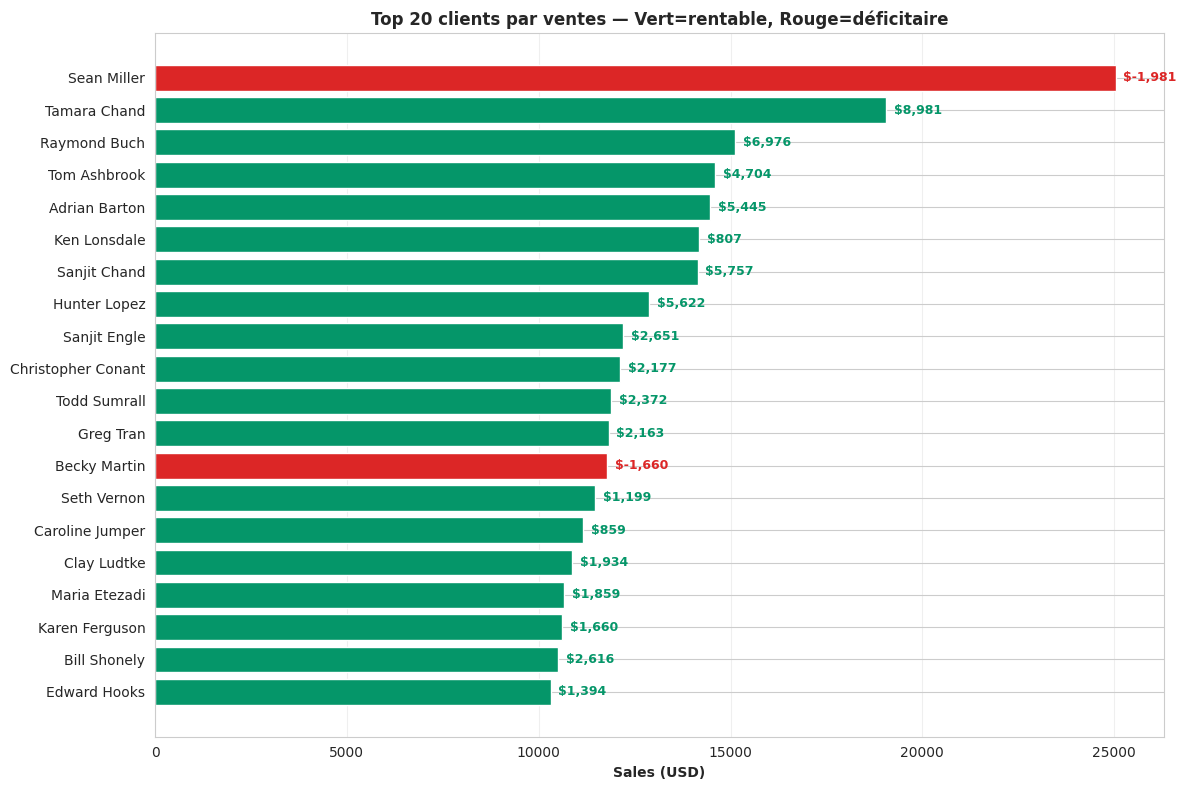


→ Sur les Top 20 clients en ventes, 18 sont rentables et 2 sont déficitaires
→ Client n°1 en ventes : Sean Miller ($25,043.05)


In [9]:
# ============================================================
# Bloc 9 : Top 20 clients par Sales
# ============================================================

# Agrégation par client
customer_stats = df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Nb_Orders=('Order ID', 'nunique')
).round(2)

customer_stats['Profit_Margin_%'] = (customer_stats['Total_Profit'] / customer_stats['Total_Sales'] * 100).round(2)

# Top 20 par ventes
top20_customers = customer_stats.sort_values('Total_Sales', ascending=False).head(20)

print("Top 20 clients par VENTES :")
print(top20_customers)

# Visualisation : Sales + couleur selon profit (rentable ou déficitaire)
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#059669' if x > 0 else '#DC2626' for x in top20_customers['Total_Profit']]
ax.barh(top20_customers.index[::-1], top20_customers['Total_Sales'].values[::-1],
        color=colors[::-1], edgecolor='white')

ax.set_xlabel('Sales (USD)', fontweight='bold')
ax.set_title('Top 20 clients par ventes — Vert=rentable, Rouge=déficitaire', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Annotation : profit en bout de barre
for i, (idx, row) in enumerate(top20_customers.iloc[::-1].iterrows()):
    profit_str = f"${row['Total_Profit']:,.0f}"
    ax.text(row['Total_Sales'] + 200, i, profit_str, va='center', fontsize=9,
            color='#059669' if row['Total_Profit'] > 0 else '#DC2626', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistiques
n_profitable = (top20_customers['Total_Profit'] > 0).sum()
print(f"\n→ Sur les Top 20 clients en ventes, {n_profitable} sont rentables et {20-n_profitable} sont déficitaires")
print(f"→ Client n°1 en ventes : {top20_customers.index[0]} (${top20_customers.iloc[0]['Total_Sales']:,.2f})")

Nombre total de clients : 793
Ventes totales : $2,297,200.86

→ Il faut 49.9% des clients (396 clients) pour atteindre 80% des ventes
→ Les 20% top clients (158 clients) génèrent 48.0% des ventes


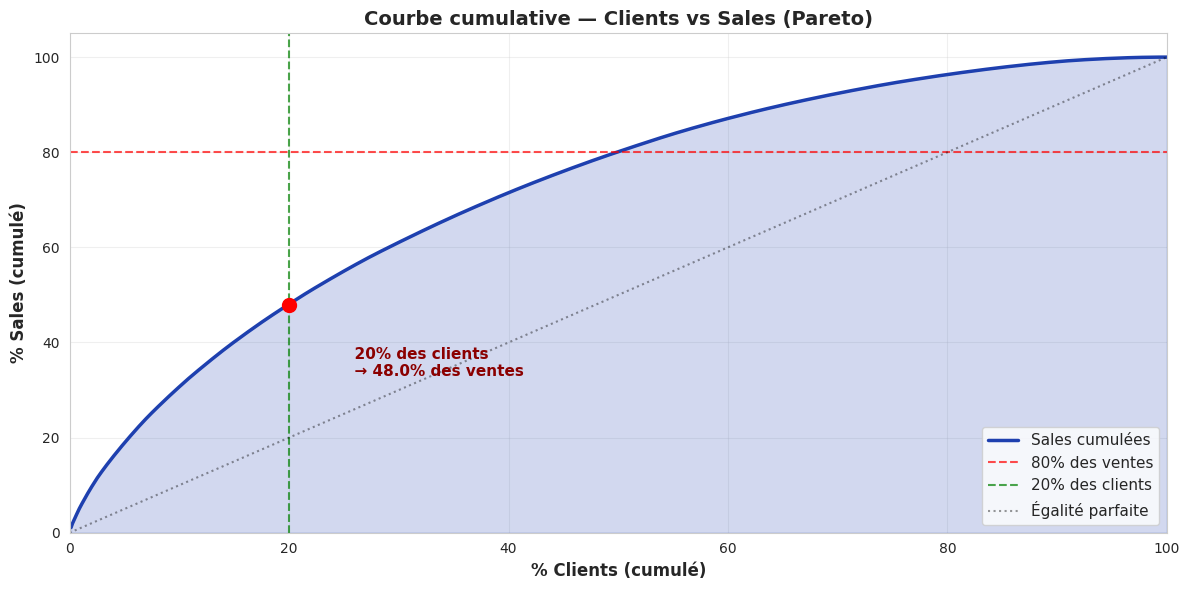


⚠️ Principe de Pareto MOINS marqué sur les ventes : 20% des clients = 48.0% des ventes
   La concentration est moins forte que sur le profit (rappel : 81.4% sur profit)


In [10]:
# ============================================================
# Bloc 10 : Pareto Clients vs Sales (Courbe Cumulative)
# ============================================================

# Tri des clients par ventes décroissantes
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

# Calcul des cumulés
cumulative_sales = customer_sales.cumsum()
total_sales = customer_sales.sum()
cumulative_pct = (cumulative_sales / total_sales) * 100

# Pourcentage de clients
n_customers = len(customer_sales)
customer_pct = (np.arange(1, n_customers + 1) / n_customers) * 100

# Seuils Pareto
idx_80 = np.argmax(cumulative_pct.values >= 80)
pct_customers_for_80 = customer_pct[idx_80]
idx_20pct = int(n_customers * 0.20)
sales_top20pct = cumulative_pct.iloc[idx_20pct - 1]

print(f"Nombre total de clients : {n_customers}")
print(f"Ventes totales : ${total_sales:,.2f}")
print(f"\n→ Il faut {pct_customers_for_80:.1f}% des clients ({idx_80+1} clients) pour atteindre 80% des ventes")
print(f"→ Les 20% top clients ({idx_20pct} clients) génèrent {sales_top20pct:.1f}% des ventes")

# Visualisation : courbe cumulative
plt.figure(figsize=(12, 6))
plt.plot(customer_pct, cumulative_pct.values, color='#1E40AF', linewidth=2.5, label='Sales cumulées')
plt.fill_between(customer_pct, cumulative_pct.values, alpha=0.2, color='#1E40AF')

# Lignes de référence 20/80
plt.axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% des ventes')
plt.axvline(20, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='20% des clients')
plt.scatter([20], [sales_top20pct], color='red', s=100, zorder=5)
plt.annotate(f'  20% des clients\n  → {sales_top20pct:.1f}% des ventes',
             xy=(20, sales_top20pct), xytext=(25, sales_top20pct - 15),
             fontsize=11, fontweight='bold', color='darkred')

# Ligne diagonale (égalité parfaite si tous les clients vendaient pareil)
plt.plot([0, 100], [0, 100], 'k:', alpha=0.4, label='Égalité parfaite')

plt.xlabel('% Clients (cumulé)', fontweight='bold', fontsize=12)
plt.ylabel('% Sales (cumulé)', fontweight='bold', fontsize=12)
plt.title('Courbe cumulative — Clients vs Sales (Pareto)', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# Conclusion
if sales_top20pct >= 75:
    print(f"\n✅ Principe de Pareto VÉRIFIÉ sur les ventes : 20% des clients = {sales_top20pct:.1f}% des ventes")
else:
    print(f"\n⚠️ Principe de Pareto MOINS marqué sur les ventes : 20% des clients = {sales_top20pct:.1f}% des ventes")
    print(f"   La concentration est moins forte que sur le profit (rappel : 81.4% sur profit)")

# 🎯 Recommandations Stratégiques — US Superstore

## Synthèse exécutive de l'analyse

---

## 1️⃣ États à prioriser pour le marketing

Les 5 États les plus rentables, à renforcer en priorité :

| État | Sales | Profit | Marge |
|---|---|---|---|
| 🥇 **California** | $457 688 | $76 381 | 16.7% |
| 🥈 **New York** | $310 876 | $74 039 | 23.8% |
| 🥉 **Washington** | $138 641 | $33 403 | 24.1% |
| **Michigan** | $76 270 | $24 463 | 32.1% |
| **Virginia** | $70 637 | $18 598 | 26.3% |

> 💡 **New York a une marge supérieure à California** malgré moins de ventes — modèle économique plus efficace.

---

## 2️⃣ États à restructurer d'urgence

10 États sur 49 sont **déficitaires**, avec une perte cumulée de **-$98 247**. Les 5 pires :

| État | Sales | Perte | Marge |
|---|---|---|---|
| 🚨 **Texas** | $170 188 | -$25 729 | -15.1% |
| 🚨 **Ohio** | $78 258 | -$16 971 | -21.7% |
| 🚨 **Pennsylvania** | $116 512 | -$15 560 | -13.4% |
| 🚨 **Illinois** | $80 166 | -$12 608 | -15.7% |
| 🚨 **North Carolina** | $55 603 | -$7 491 | -13.5% |

> ⚠️ **Le Texas est paradoxal** : 3ème en ventes mais champion des pertes. Cause probable : remises excessives ou coûts logistiques.

---

## 3️⃣ Villes à prioriser (Top 5 Profit)

| Ville | Sales | Profit | Marge |
|---|---|---|---|
| ✅ **New York City** | $256 368 | $62 037 | 24.2% |
| ✅ **Los Angeles** | $175 851 | $30 441 | 17.3% |
| ✅ **Seattle** | $119 541 | $29 156 | 24.4% |
| ✅ **San Francisco** | $112 669 | $17 507 | 15.5% |
| ✅ **Detroit** | $42 447 | $13 182 | 31.1% |

---

## 4️⃣ Villes à réviser (Top 5 PERTES)

| Ville | Sales | Perte | Marge |
|---|---|---|---|
| 🚨 **Philadelphia** | $109 077 | -$13 838 | -12.7% |
| 🚨 **Houston** | $64 505 | -$10 154 | -15.7% |
| 🚨 **San Antonio** | $21 844 | -$7 299 | **-33.4%** |
| 🚨 **Chicago** | $48 540 | -$6 655 | -13.7% |
| 🚨 **Burlington** | $21 668 | -$3 623 | -16.7% |

> ⚠️ **San Antonio** : marge catastrophique de -33% → chaque dollar vendu coûte 33 cents en perte !

---

## 5️⃣ Pépites cachées 💎

Petites villes ultra-rentables (marge > 30%, ventes < $30k) :

| Ville | Sales | Profit | Marge |
|---|---|---|---|
| 💎 **Atlanta** | $17 198 | $6 994 | **40.7%** |
| 💎 **Minneapolis** | $16 871 | $6 825 | **40.5%** |
| 💎 **Lafayette** | $25 036 | $10 018 | **40.0%** |
| 💎 **Providence** | $15 981 | $5 506 | **34.5%** |
| 💎 **Detroit** | $42 447 | $13 182 | **31.1%** |

> 💎 Ces villes sont des **modèles à reproduire** : faible volume mais excellente conversion en profit.

---

## 6️⃣ Stratégie de fidélisation (Principe de Pareto)

| Dimension | 20% des clients génèrent | Pareto vérifié ? |
|---|---|---|
| **Profit** | **81.4%** | ✅ Oui |
| **Sales** | **48.0%** | ❌ Non |

**Implications :**
- 🎯 Créer un programme **CRM VIP** pour les **158 clients top profit** (81.4% du profit total)
- 🎯 Segmenter à 2 niveaux : VIP profit + clients à fort volume
- ⚠️ **Sean Miller** : n°1 en ventes mais déficitaire (-$1 981) → renégocier les discounts
- ⭐ **Tom Ashbrook** (NY) : modèle parfait, $4 599 de profit en 2 commandes → identifier d'autres profils similaires

---

## 7️⃣ Actions concrètes à mettre en œuvre

| # | Action | Cible | Impact attendu |
|---|---|---|---|
| ① | Réduire les discounts moyens | Texas | Économiser $25 729 |
| ② | Lancer campagne fidélisation VIP | 158 clients top | Sécuriser 81.4% du profit |
| ③ | Audit produit & logistique | Philadelphia, Houston | Stopper $24 000 de pertes |
| ④ | Marketing local intensif | Minnesota, Delaware | Croissance ciblée marge 36%+ |
| ⑤ | Renégocier remises clients | Sean Miller, Becky Martin | Récupérer $3 640 de marge |
| ⑥ | Standardiser modèle "pépite" | Atlanta, Minneapolis | Dupliquer marge 40% ailleurs |
| ⑦ | Restructurer 10 États déficitaires | Texas, Ohio, PA, IL... | Récupérer ~$100 000 |

---

## 📊 Récapitulatif global de l'analyse

| Métrique | Valeur |
|---|---|
| Total commandes | 9 994 |
| Total clients | 793 |
| Ventes globales | **$2 297 201** |
| Profit global | **$286 397** |
| Marge globale | **12.5%** |
| États rentables / déficitaires | 39 ✅ / 10 🚨 |
| Perte cumulée des 10 États déficitaires | **-$98 247** |
| % du profit issu de 20% des clients | **81.4%** |
| Top client profit | Tom Ashbrook ($4 599) |
| Top ville profit | New York City ($62 037) |
| Top État profit | California ($76 381) |

---

## 🎓 Insights clés

1. **California domine les ventes** mais **NY est plus rentable** par dollar vendu
2. **10 États sur 49 perdent de l'argent** → audit urgent nécessaire
3. **Pareto vérifié sur le profit** (20%/81%) mais pas sur les ventes (20%/48%)
4. **Certaines grosses villes perdent de l'argent** (Philadelphia, Houston, San Antonio)
5. **Petites villes peuvent être ultra-rentables** (Atlanta, Minneapolis : marge >40%)
6. **Quelques gros clients sont déficitaires** → revoir leur tarification

---

*Document de synthèse — Mini-projet US Superstore Data Analysis*